# Customer Churn Analysis 📊

## Overview
Machine learning analysis to predict customer churn
for a telecom company using Random Forest classifier.

## Tools Used
- Python (Pandas, Scikit-learn, Matplotlib, Seaborn)
- Machine Learning (Random Forest)

## Key Findings
- Overall churn rate: 26.5%
- Month-to-month contracts have 42% churn rate
- Two-year contracts have only 3% churn rate
- Model accuracy: 80%
- Top churn factors: Total Charges, Monthly Charges, Tenure

## Dataset
Telco Customer Churn Dataset (IBM/Kaggle) - 7,043 customers


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:

from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

print("Missing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts())


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nData cleaned successfully!")
print("Churn rate:", round(df['Churn'].mean() * 100, 1), "%")

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data cleaned successfully!
Churn rate: 26.5 %


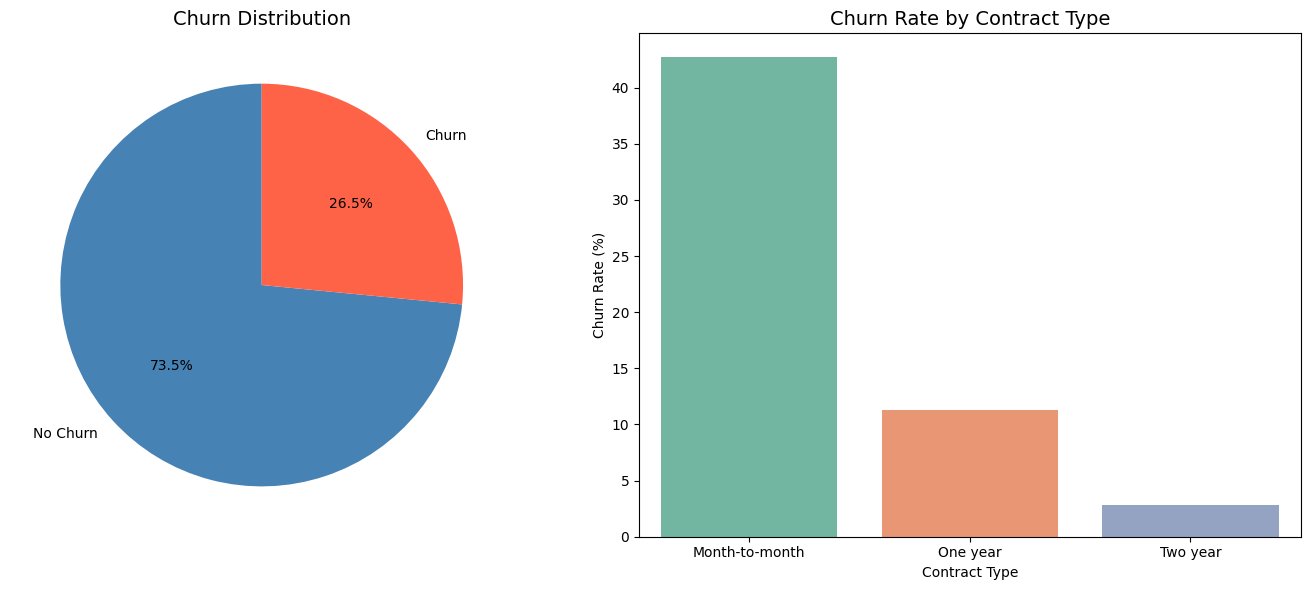

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].pie(df['Churn'].value_counts(),
            labels=['No Churn', 'Churn'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Churn Distribution', fontsize=14)


contract_churn = df.groupby('Contract')['Churn'].mean() * 100
sns.barplot(x=contract_churn.index, y=contract_churn.values,
            hue=contract_churn.index, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Churn Rate by Contract Type', fontsize=14)
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [6]:

df_ml = df.drop('customerID', axis=1)
le = LabelEncoder()
categorical_cols = df_ml.select_dtypes(include='object').columns
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])


X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



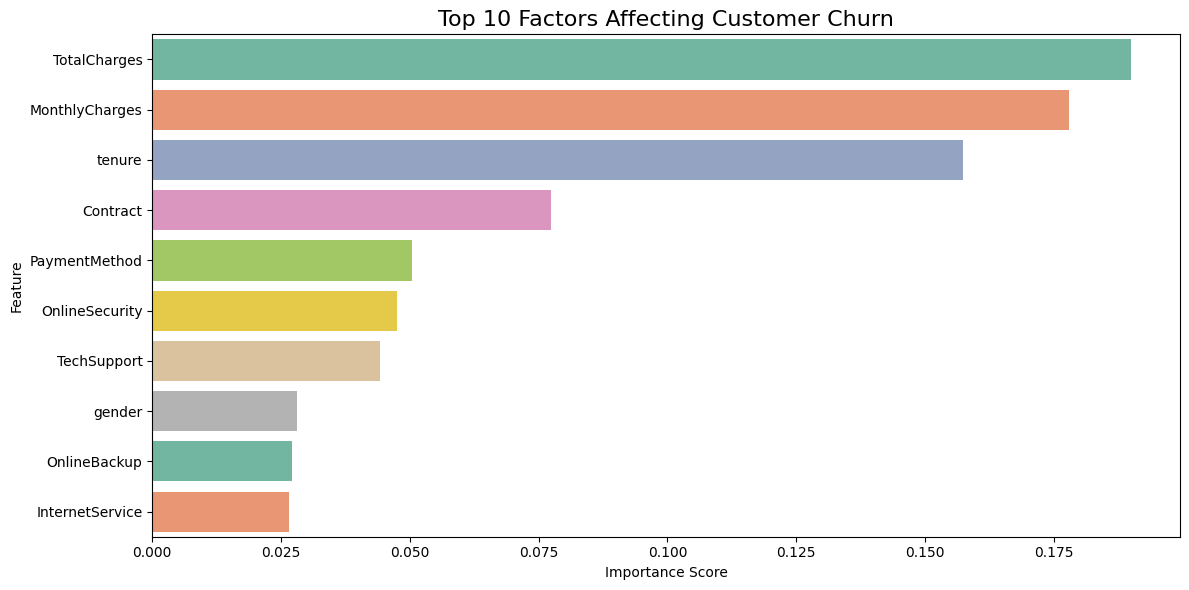

            feature  importance
18     TotalCharges    0.189992
17   MonthlyCharges    0.177867
4            tenure    0.157428
14         Contract    0.077357
16    PaymentMethod    0.050379
8    OnlineSecurity    0.047432
11      TechSupport    0.044190
0            gender    0.028117
9      OnlineBackup    0.027067
7   InternetService    0.026444


In [7]:

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='importance', y='feature',
            hue='feature', palette='Set2', legend=False)
plt.title('Top 10 Factors Affecting Customer Churn', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance)